<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FAQ4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Handle missing values

# Fill missing values in Age using the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing values in Embarked using the mode (most frequent value)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the Cabin column because it contains too many missing values
df.drop("Cabin", axis=1, inplace=True)

# Verify that all missing values have been handled
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print("Number of Duplicate Records:", duplicates)

# Remove duplicates if any exist
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

# Verify the dataset shape after removing duplicates
print("Dataset Shape:", df.shape)

Number of Duplicate Records: 0
No duplicate records found.
Dataset Shape: (891, 11)


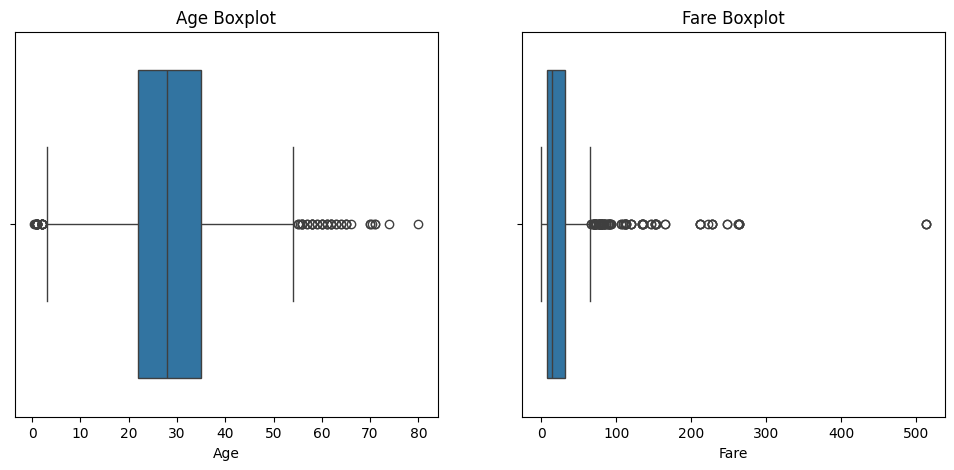

Dataset Shape After Removing Outliers: (775, 11)


In [ ]:
# Display boxplots to detect outliers

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")

plt.show()

# Remove outliers from Fare using the IQR method

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["Fare"] >= lower_limit) & (df["Fare"] <= upper_limit)]

print("Dataset Shape After Removing Outliers:", df.shape)

In [ ]:
# -------------------------------
# Feature Engineering
# -------------------------------

# 1. Create FamilySize feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 2. Extract Title from the Name column
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

# 3. Create AgeGroup feature
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Display the newly created features
print(df[["Name", "FamilySize", "Title", "AgeGroup"]].head())

                                           Name  FamilySize Title     AgeGroup
0                       Braund, Mr. Owen Harris           2    Mr  Young Adult
2                        Heikkinen, Miss. Laina           1  Miss  Young Adult
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)           2   Mrs  Young Adult
4                      Allen, Mr. William Henry           1    Mr  Young Adult
5                              Moran, Mr. James           1    Mr  Young Adult


<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1688/3406120826.py:9: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


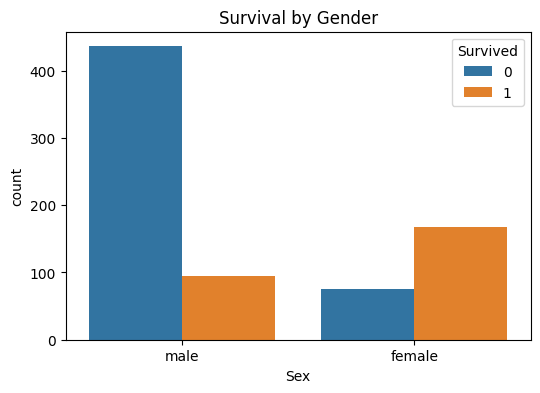

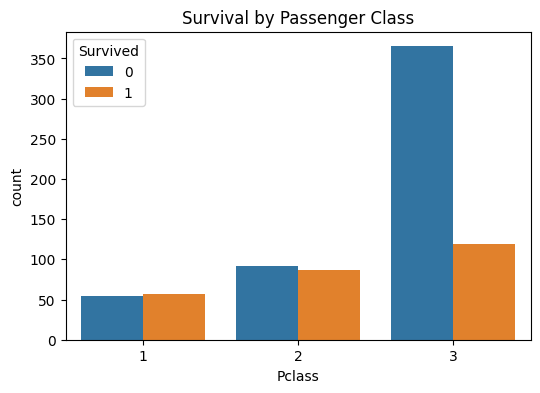

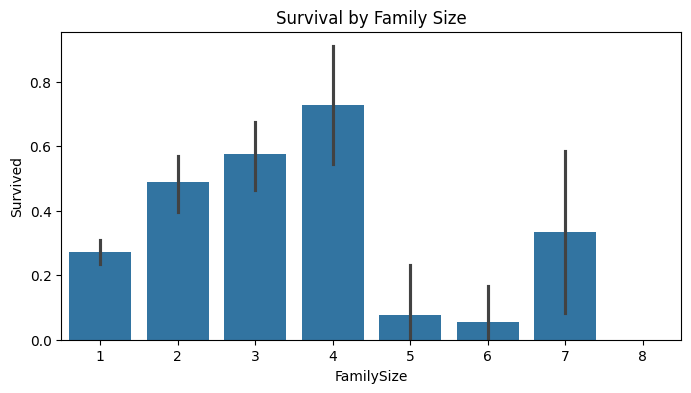

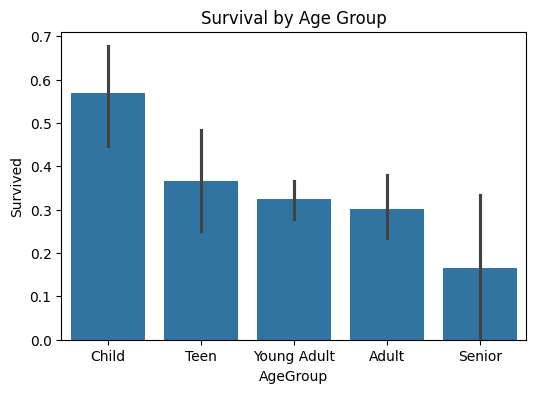

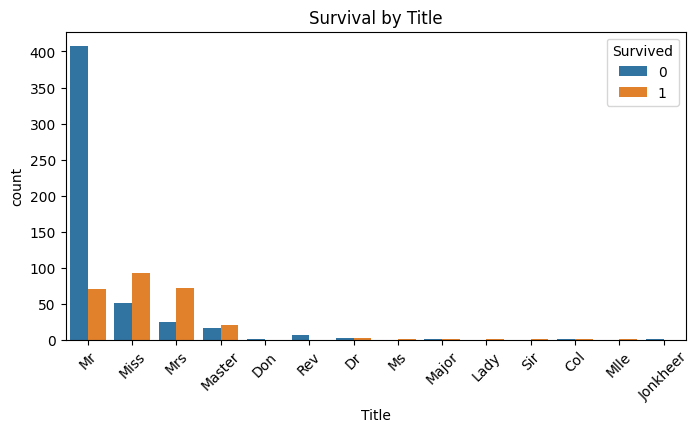

In [ ]:
# ---------------------------------
# Exploratory Data Analysis (EDA)
# ---------------------------------

# Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Survival by Family Size
plt.figure(figsize=(8,4))
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival by Family Size")
plt.show()

# Survival by Age Group
plt.figure(figsize=(6,4))
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival by Age Group")
plt.show()

# Survival by Title
plt.figure(figsize=(8,4))
sns.countplot(x="Title", hue="Survived", data=df)
plt.xticks(rotation=45)
plt.title("Survival by Title")
plt.show()

In [ ]:
# Display the first five rows of the final cleaned dataset
print("Final Cleaned Dataset:")
print(df.head())

# Save the cleaned dataset as a CSV file
df.to_csv("Titanic_Cleaned.csv", index=False)

print("\nDataset has been successfully saved as 'Titanic_Cleaned.csv'")

Final Cleaned Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    male  22.0      1      0   
2                        Heikkinen, Miss. Laina  female  26.0      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0   
4                      Allen, Mr. William Henry    male  35.0      0      0   
5                              Moran, Mr. James    male  28.0      0      0   

             Ticket     Fare Embarked  FamilySize Title     AgeGroup  
0         A/5 21171   7.2500        S           2    Mr  Young Adult  
2  STON/O2. 3101282   7.9250        S           1  Miss  Young Adult  
3            113803  53.1000        S           2   Mrs  Young Adult  
4